# Cost calculations for neuro-foundation models

This notebook approximates the costs of building different classes of foundation models for neuroscience. One of the key factors in determining the cost is the cost of generation and retention of data. There are three main classes of foundation models: 1) **E2E**; 2) **E2N**; 3) **N2N**. E2E class has two subclasses: 1) **E2E-simulation**. This subclass uses virtual environments to produce experiential data using GPUs.; 2) **E2E-public**. This subclass relies on publicly available data from the internet and online repositories. 

The costs associated with each class falls into the following three categories: 1) Acquisition. It includes the upfront cost that needs to be paid in order to enable data collection.; 2) Curation/Generation. The labor cost associated with curating and annotating the data or alternatively generate the data in simulation.; 3) Storage. The cost associated with storage of the data over the duration of the project. 

The cost subtypes associated with each class is as follows: 

**Acquisition**: 
E2N and N2N require acquisition of a microscope/electrophysioly setup, animal subjects, supporting costs. 

Equal proportion of mouse and macaque subjects are assumed. Each mouse and macaque subject is assumed to contribute to 100 and 1000 hours of data collection respectivley. 

2-photon microscope system construction cost: $400k-1Million
Mouse purchase cost: $130 / animal 
Macaque monkey purchase cost: $30k / animal 
Rig + support (surgical tools, acquisition equipment): $100k for 10,000 hours of recording. 

**Curation**: 
1. E2E. E2E-simulation requires GPUs to generate and if necessary annotate the data. The cost is calcualted per GPU per hour considering the rate of data production. E2E-public requires curation of experintial datasets which introduces labor cost. 

2. N2N and E2N. Require labor costs for collecting neural data, curating different neural datasets. 

**Storage**: 
All classes require data storage costs calculated monthly according to the number of data points. For each approach the per data point storage size can be calcluated and the monthly storage cost as a function of number of data points is calculated. One data point is considered as one second of activity collected from an information stream. E2N data consists of equal number of experiential and neural data points. The experiential data is assumed to consist of 60% text, 20% video, and 20% images.


*Per unit data size*:
Video data: 1 second of 1080p colored video (1080p resolution, 30 fps, H.264: 6.22 MB)
Image data: 1 500px500p Jpeg (0.1 MB) 
Text data: 1 character (4 Bytes)
Electrophysiology and imaging: 1 second of 1000 sites (0.02 MB; assuming spike storage size of 2 B/spike and average spike frequency of 10Hz). 

*Labor*:
Labor cost for data collection and curation: $30/hr 
Neural data curation rate: 1000 data point/hr
Experience data curation rate: 10000 data point/hr (experiential data points are of much larger size than neural datasets and so the labor rate is estimated lower)

Cloud-based storage cost: 0.023/GB/month

Operational: 
Animal per-diem: $1-5 /day / animal 
GPU-based data generation
Data generation rate: 10 units/sec/gpu
GPU cost: $2 /hr/gpu


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# -----------------------------
# Parameters
# -----------------------------
params = {
    'labor_cost_per_hr': 30.0,
    'neural_curation_rate_pts_per_hr': 1000.0,
    'experience_curation_rate_pts_per_hr': 10000.0,
    'gpu_gen_rate_pts_per_sec': 10.0,
    'gpu_cost_per_hr': 2.0,
    'storage_cost_per_gb_month': 0.023,
    'bytes_per_point': {
        'video': 6.22 * 1024**2,
        'image': 0.1 * 1024**2,
        'text': 4.0,
        'neural': 0.02 * 1024**2,
    },
    'mouse_hour_fraction': 0.5,
}
hardware = {
    'two_photon_cost': 700_000.0,  # midpoint of 400k-1M
    'two_photon_hours_capacity': 40000.0,
    'rig_support_cost': 100000.0,
    'rig_support_hours_capacity': 10000.0,
    'mouse_cost': 130.0,
    'mouse_hours_capacity': 100.0,
    'macaque_cost': 30000.0,
    'macaque_hours_capacity': 1000.0,
}
per_diem = {
    'rate_per_day': 3.0,
    'apply': True,
}
# Define data modality mix per class (fractions sum to 1.0)
data_mix = {
    'E2E-simulation': {'text': 0.6, 'video': 0.2, 'image': 0.2},
    'E2E-public': {'text': 0.6, 'video': 0.2, 'image': 0.2},
    'E2N': {'neural': 1.0, 'text': 0.6, 'video': 0.2, 'image': 0.2}, # The ratios add up to 2.0 because in E2N both the experiential and neural data need to be collected and stored.
    'N2N': {'neural': 1.0},
}
classes = ['E2E-simulation', 'E2E-public', 'E2N', 'N2N']
# -----------------------------
# Cost functions
# -----------------------------
def storage_cost_per_point_per_month(mix, params):
    bytes_per_point = 0.0
    for modality, frac in mix.items():
        bytes_per_point += frac * params['bytes_per_point'][modality]
    gb_per_point = bytes_per_point / (1024**3)
    return gb_per_point * params['storage_cost_per_gb_month']

def curation_cost_per_point(class_name, params):
    if class_name == 'E2E-simulation':
        pts_per_hr = params['gpu_gen_rate_pts_per_sec'] * 3600.0
        return params['gpu_cost_per_hr'] / pts_per_hr
    if class_name == 'E2E-public':
        return params['labor_cost_per_hr'] / params['experience_curation_rate_pts_per_hr']
    if class_name == 'E2N':
        # E2N has both neural and experiential data; equal weighting
        neural_cost = params['labor_cost_per_hr'] / params['neural_curation_rate_pts_per_hr']
        experiential_cost = params['labor_cost_per_hr'] / params['experience_curation_rate_pts_per_hr']
        return neural_cost + experiential_cost
    # For N2N, only neural data
    return params['labor_cost_per_hr'] / params['neural_curation_rate_pts_per_hr']

def acquisition_cost_neural(n_neural_points, months, params, hardware, per_diem):
    hours_needed = n_neural_points / 3600.0
    # Split between mouse and macaque hours
    mouse_hours = hours_needed * params['mouse_hour_fraction']
    macaque_hours = hours_needed * (1.0 - params['mouse_hour_fraction'])
    mice_needed = np.ceil(np.maximum(mouse_hours, 0.0) / hardware['mouse_hours_capacity'])
    macaques_needed = np.ceil(np.maximum(macaque_hours, 0.0) / hardware['macaque_hours_capacity'])
    # Equal split between imaging and ephys
    imaging_hours = hours_needed / 2.0
    microscopes_needed = np.ceil(np.maximum(imaging_hours, 0.0) / hardware['two_photon_hours_capacity'])
    rigs_needed = np.ceil(np.maximum(hours_needed, 0.0) / hardware['rig_support_hours_capacity'])
    base_cost = (
        mice_needed * hardware['mouse_cost'] +
        macaques_needed * hardware['macaque_cost'] +
        microscopes_needed * hardware['two_photon_cost'] +
        rigs_needed * hardware['rig_support_cost']
    )
    if per_diem['apply']:
        days = months * 30.0
        per_diem_cost = (mice_needed + macaques_needed) * per_diem['rate_per_day'] * days
    else:
        per_diem_cost = 0.0
    return base_cost + per_diem_cost

def total_cost(class_name, n_points, months, params, data_mix, hardware, per_diem):
    if class_name == 'E2E-simulation':
        storage = 0.0
    else:
        storage_per_point_per_month = storage_cost_per_point_per_month(data_mix[class_name], params)
        storage = storage_per_point_per_month * (n_points) * months
    curation_per_point = curation_cost_per_point(class_name, params)
    curation = curation_per_point * n_points
    if class_name in ('E2N', 'N2N'):
        acquisition = acquisition_cost_neural(n_points, months, params, hardware, per_diem)
    else:
        acquisition = 0.0
    return acquisition + curation + storage


In [2]:
# Figure styling (Nature Neuroscience-like: clean axes, larger text)
import matplotlib as mpl

mpl.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'lines.linewidth': 2.0,
    'lines.markersize': 6.0,
    'legend.fontsize': 10,
    'legend.frameon': False,
})

def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1)
    ax.grid(False)

def style_3d(ax):
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_edgecolor((1, 1, 1, 0))
        axis.pane.set_facecolor((1, 1, 1, 0))
        axis._axinfo['grid']['linewidth'] = 0


# Grid + plot

In [3]:
%matplotlib widget

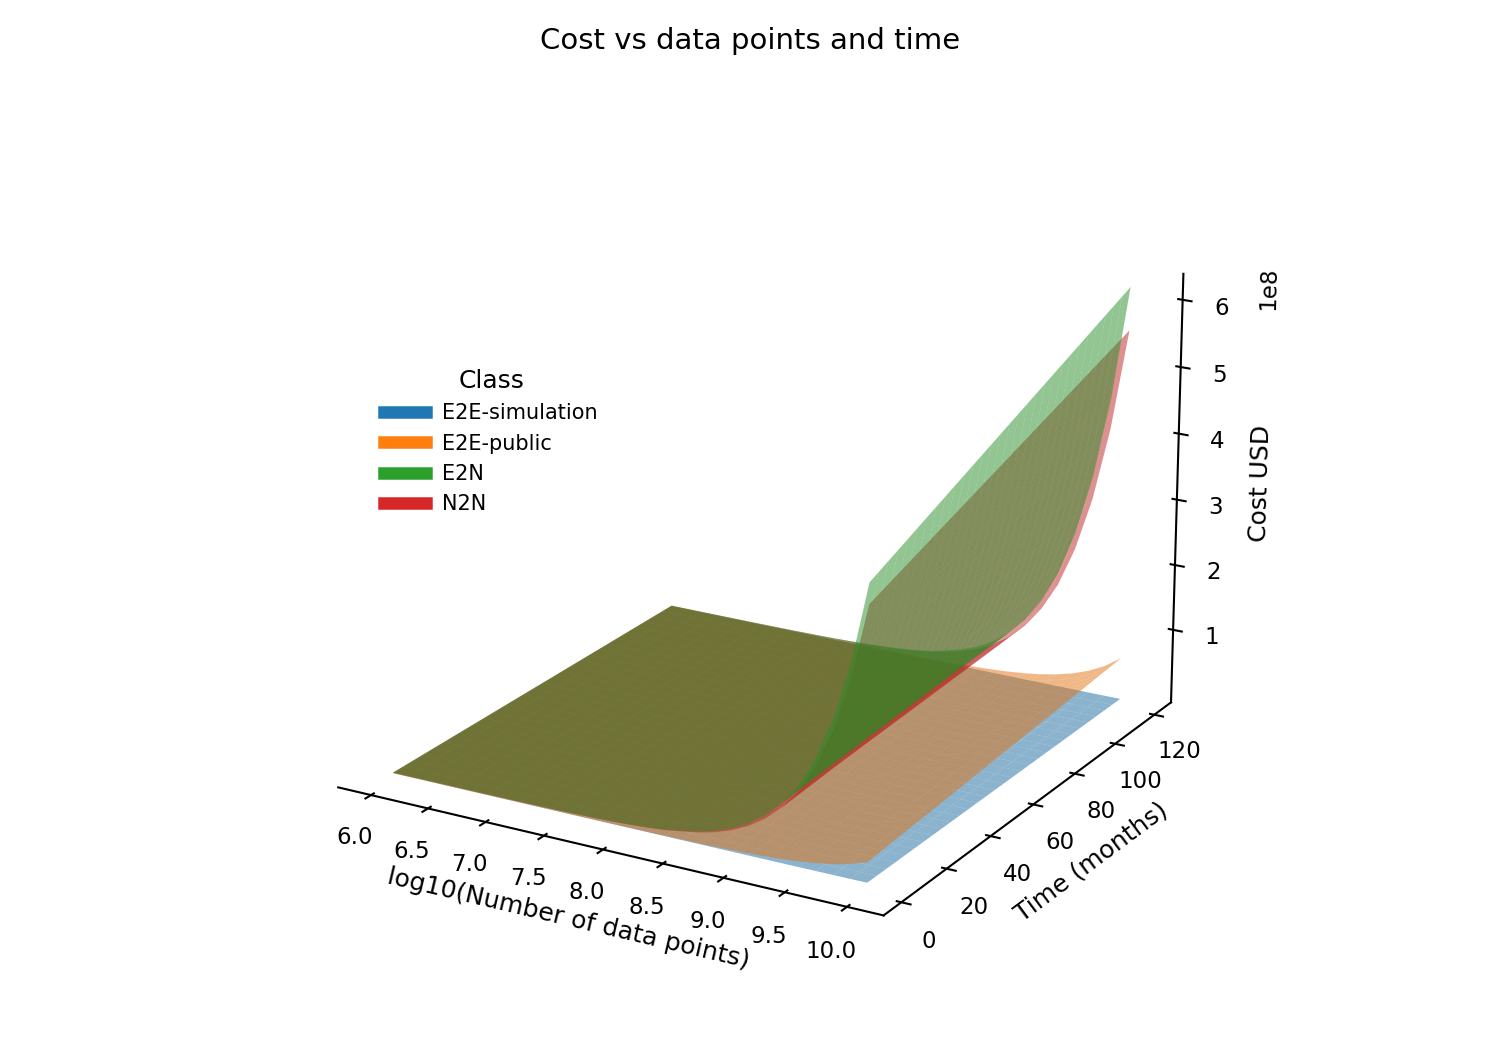

In [8]:
n_points_grid = np.logspace(6, 10, 30)
months_grid = np.linspace(1, 120, 30)
N, T = np.meshgrid(n_points_grid, months_grid)

# mplot3d does not handle log scales well; transform axes explicitly
X = np.log10(N)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
legend_handles = []

eps = 1e-9  # avoid log10(0)

for i, class_name in enumerate(classes): # enumerate(classes):  enumerate(['E2E-public', 'N2N']):
    Z = total_cost(class_name, N, T, params, data_mix, hardware, per_diem)
    # Z_log = np.log10(Z + eps)
    color = colors[i % len(colors)]
    ax.plot_surface(X, T, Z, alpha=0.5, linewidth=0, antialiased=True, color=color)
    legend_handles.append(plt.Line2D([0], [0], color=color, lw=6, label=class_name))

ax.set_xlabel('log10(Number of data points)')
ax.set_ylabel('Time (months)')
ax.set_zlabel('Cost USD')
ax.set_title('Cost vs data points and time')
ax.view_init(elev=20, azim=-60)
style_3d(ax)
ax.legend(handles=legend_handles, title='Class', loc='upper left', bbox_to_anchor=(0.1, 0.7))
plt.tight_layout()
plt.savefig('cost_vs_data_points_and_time_surface.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [29]:
%matplotlib inline

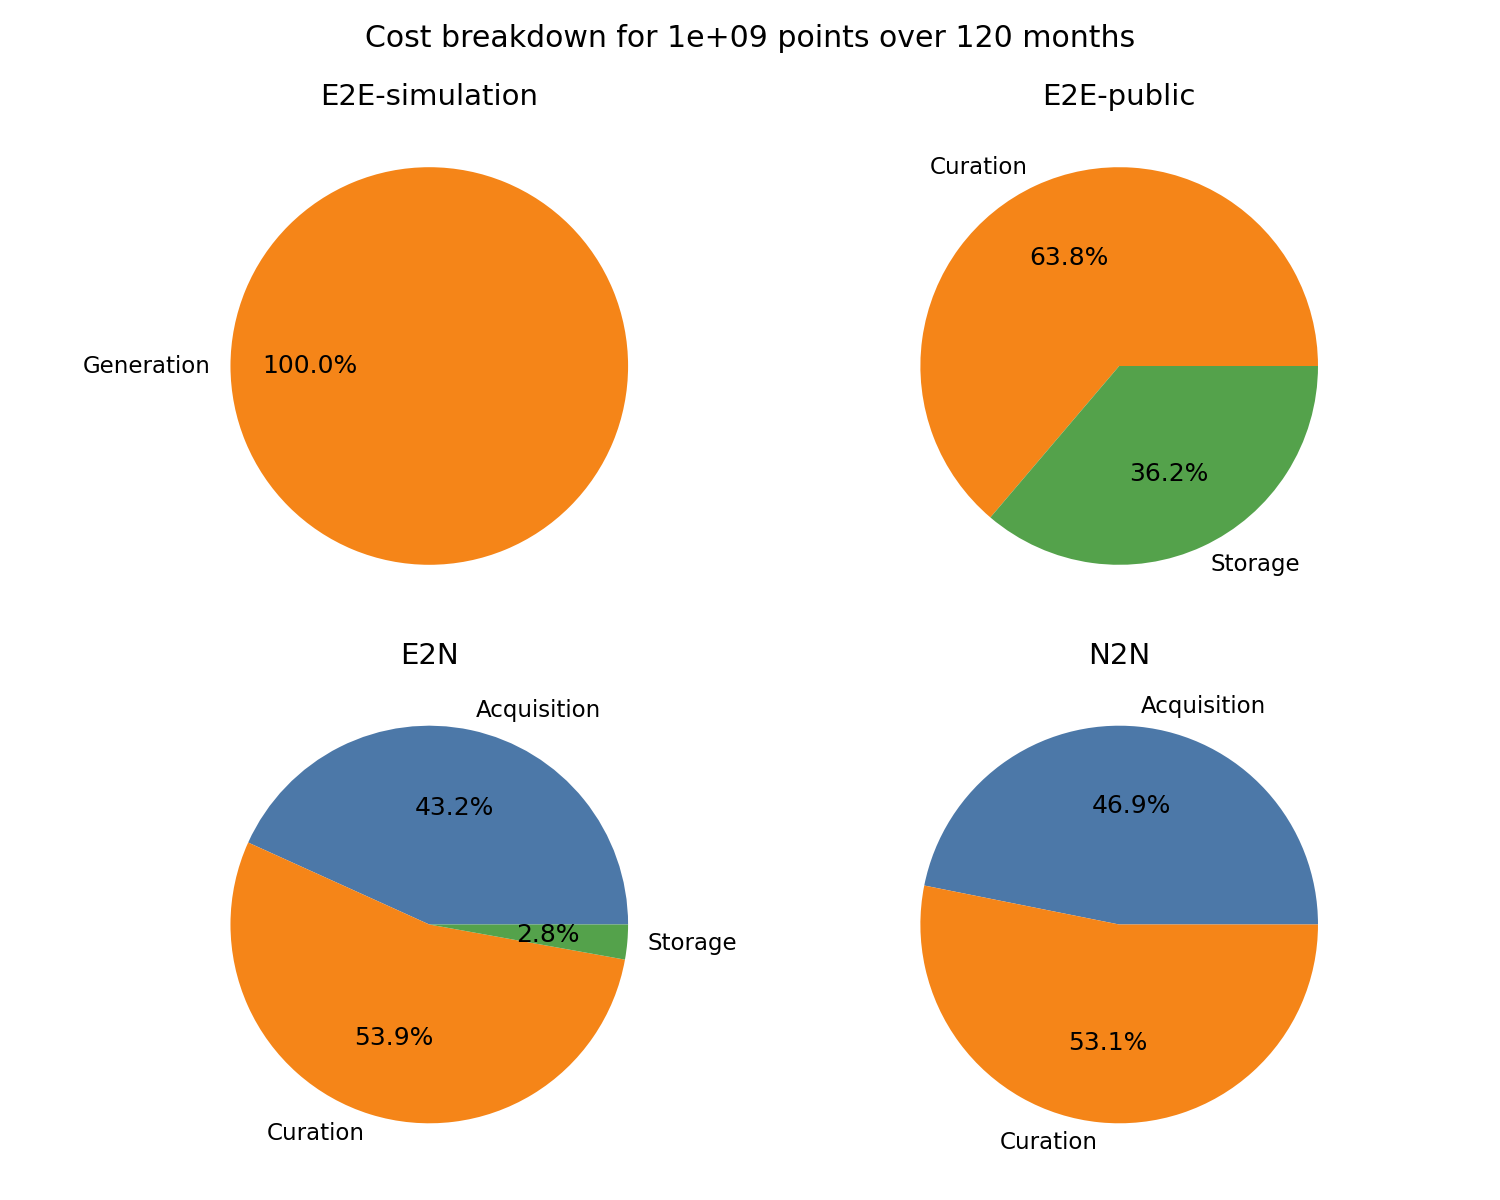

In [9]:
# Pie charts of cost breakdown by class
n_points_pie = 1e9
months_pie = 120

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

labels = ['Acquisition', 'Curation', 'Storage']
colors = {
    'Acquisition': '#4C78A8',
    'Curation': '#F58518',
    'Generation': '#F58518',
    'Storage': '#54A24B',
}

for ax, class_name in zip(axes, classes):
    # storage
    if class_name == 'E2E-simulation':
        storage = 0.0
    else:
        storage_ppm = storage_cost_per_point_per_month(data_mix[class_name], params)
        storage = storage_ppm * (n_points_pie / 2.0) * months_pie

    # curation
    curation_pp = curation_cost_per_point(class_name, params)
    curation = curation_pp * n_points_pie

    # acquisition
    if class_name in ('E2N', 'N2N'):
        n_neural_points = n_points_pie * data_mix[class_name].get('neural', 0.0)
        acquisition = acquisition_cost_neural(n_neural_points, months_pie, params, hardware, per_diem)
    else:
        acquisition = 0.0

    values = [acquisition, curation, storage]
    
    # Use 'Generation' label for E2E-simulation, 'Curation' for others
    class_labels = ['Acquisition', 'Generation' if class_name == 'E2E-simulation' else 'Curation', 'Storage']

    total = sum(values)
    keep = [(v, l) for v, l in zip(values, class_labels) if total > 0 and (v / total) >= 0.01]
    if keep:
        values_plot, labels_plot = zip(*keep)
        colors_plot = [colors[l] for l in labels_plot]
    else:
        values_plot, labels_plot, colors_plot = [0.0], ['No costs'], ['#B0B0B0']

    ax.pie(values_plot, labels=labels_plot, autopct='%1.1f%%', colors=colors_plot)
    ax.set_title(class_name)
    ax.set_aspect('equal')

plt.suptitle(f'Cost breakdown for {n_points_pie:.0e} points over {months_pie} months')
plt.tight_layout()
plt.savefig('cost_breakdown_pie_charts.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
%matplotlib inline

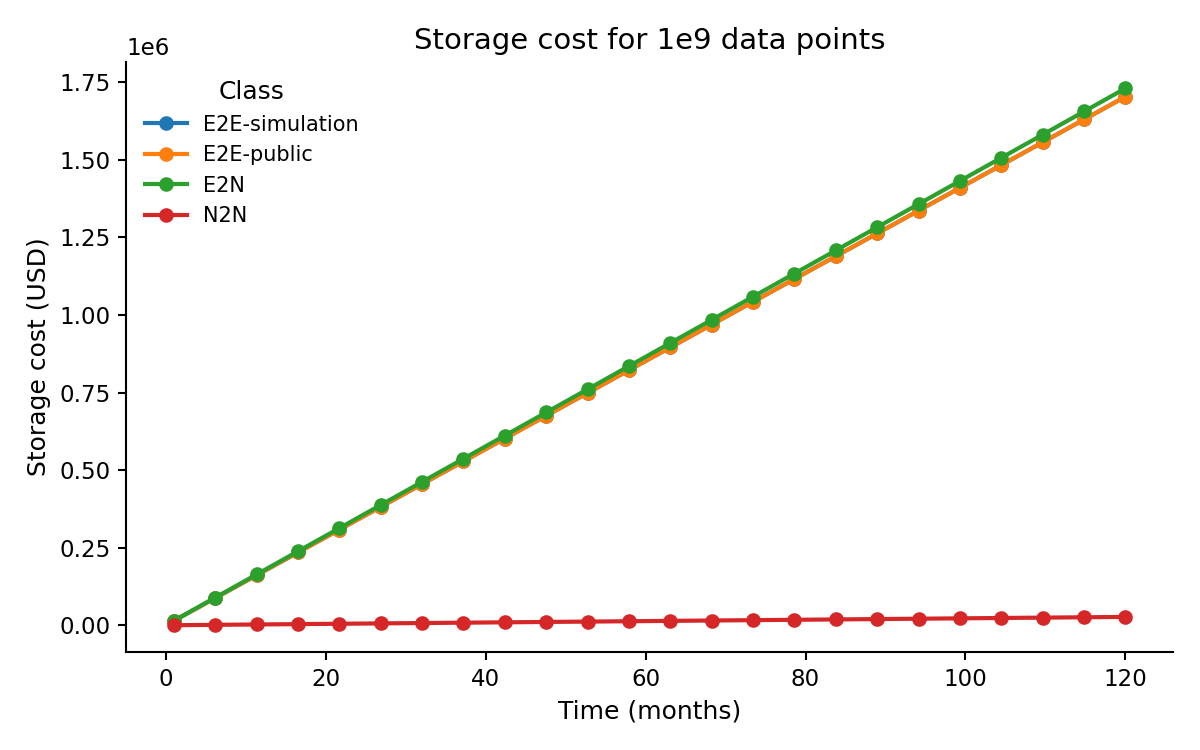

In [10]:
# Storage cost vs time for 1e9 points across classes
n_points = 1e9
months = np.linspace(1, 120, 24)

fig, ax = plt.subplots(figsize=(8, 5))

for class_name in classes: #  ['N2N'] classes
    storage_per_point_per_month = storage_cost_per_point_per_month(data_mix[class_name], params)
    storage = storage_per_point_per_month * (n_points / 2.0) * months
    ax.plot(months, storage, label=class_name, marker='o')
    # ax.set_yscale('log')
    # ax.set_xscale('log')

ax.set_xlabel('Time (months)')
ax.set_ylabel('Storage cost (USD)')
ax.set_title('Storage cost for 1e9 data points')
ax.legend(title='Class')
style_axes(ax)
plt.tight_layout()
plt.savefig('storage_cost_vs_time.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [24]:
%matplotlib inline

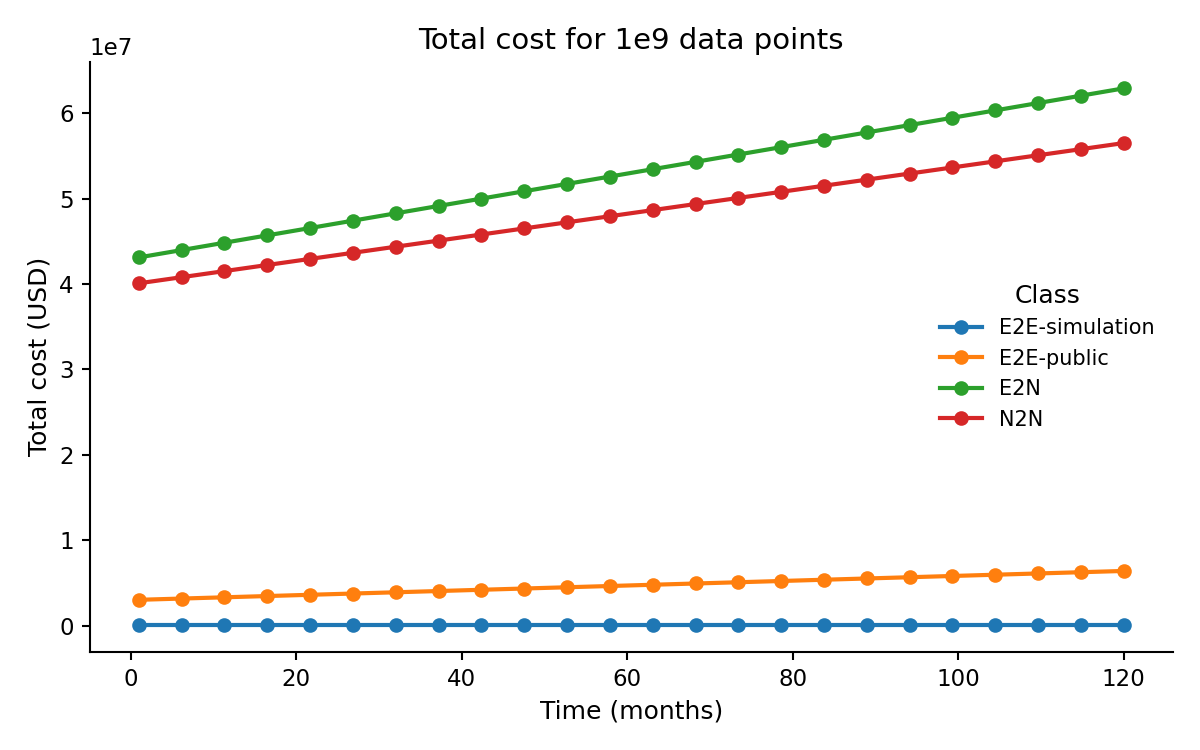

In [11]:
# Total cost vs time for 1e9 points across classes
months = np.linspace(1, 120, 24)
n_points = np.ones(24) * 1e9

fig, ax = plt.subplots(figsize=(8, 5))

for class_name in classes:
    Z = total_cost(class_name, n_points, months, params, data_mix, hardware, per_diem)
    ax.plot(months, Z, label=class_name, marker='o')
    # ax.set_yscale('log')

ax.set_xlabel('Time (months)')
ax.set_ylabel('Total cost (USD)')
ax.set_title('Total cost for 1e9 data points')
ax.legend(title='Class')
style_axes(ax)
plt.tight_layout()
plt.savefig('total_cost_vs_time.pdf', dpi=300, bbox_inches='tight')
plt.show()

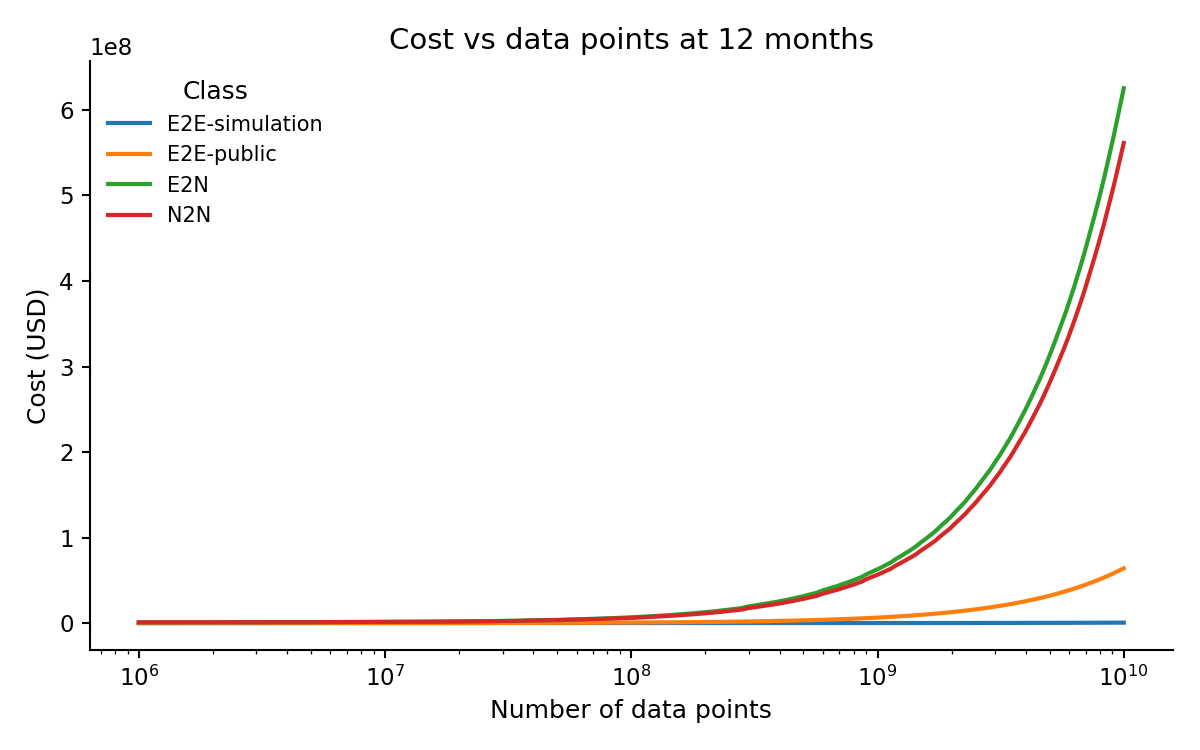

In [12]:
# Cost vs data points at 120 months
months_fixed = 120
n_points_grid_1d = np.logspace(6, 10, 200)

fig, ax = plt.subplots(figsize=(8, 5))

for class_name in classes:
    Z = total_cost(class_name, n_points_grid_1d, months_fixed, params, data_mix, hardware, per_diem)
    ax.plot(n_points_grid_1d, Z, label=class_name)

ax.set_xscale('log')
ax.set_xlabel('Number of data points')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost vs data points at 12 months')
ax.legend(title='Class')
ax.set_xscale('log')
# ax.set_yscale('log')
style_axes(ax)
plt.tight_layout()
plt.savefig('cost_vs_data_points.pdf', dpi=300, bbox_inches='tight')
plt.show()
